In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Pressure, dilution, and the three equilibrium ratios (Illustrations 13.1-4 and 13.1-6, Figure 13.1-2)

$$\tfrac12\mathrm{N_2}+\tfrac32\mathrm{H_2}\;\rightleftharpoons\;\mathrm{NH_3}
\qquad\qquad
K_a=K_\nu K_y\left(\frac{P}{1\ \rm bar}\right)^{\sum_i\nu_i}$$

Ammonia synthesis at 450 K, asked four ways. $K_a$ is the same number in every one of them
-- **1.218** -- and everything that differs happens on the composition side, which is what
makes the four worth keeping together.

| | the question | what it isolates |
|---|---|---|
| **13.1-4a** | stoichiometric feed at 4 bar | the base case |
| **13.1-4b** | equal N$_2$, H$_2$ and an inert at 4 bar | dilution **suppresses** this reaction, where it *promoted* N$_2$O$_4$ dissociation -- because $\Delta\nu$ has the opposite sign |
| **13.1-4c** | constant **volume**, starting at 4 bar | the pressure falls as the reaction proceeds, so the reaction partly relieves its own suppression |
| **13.1-6** | $K_a$, $K_p$ and $K_y$ for the same state | that the three ratios are three bookkeepings of one equilibrium, and only one of them is a constant |

**This is the ideal-gas twin of `high_pressure_ammonia_equilibrium`**, which does
Illustration 13.1-8 on the same reaction with an equation of state. Read together, the pair
is a controlled experiment on what the fugacity coefficients are worth: here $K_\nu=1$ by
assumption, there it is computed and falls to 0.045.

**Figure 13.1-2** belongs with these because it is the same operation done eight times:
$K_a$ carried from 25 $^{\circ}$C to reaction temperature, for eight reactions at once.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad

from thermo.reaction import Reaction, equilibrium_extent, reaction_cp
from thermo.reaction import R          # scipy.constants.R, 8.314462...
from thermo.charts import use_book_style
use_book_style()

# TAKE R FROM THE MODULE, do not retype it. Two of Figure 13.1-2's reactions are
# integrated by hand below and checked against `Reaction.ln_Ka`; with a hand-typed 8.314
# the two routes disagree by 3e-3 in ln Ka, which looks exactly like an integration error
# and is only the gas constant.
print(f"R = {R!r}")
T_RXN = 450.0

ammonia = Reaction.parse("0.5 N2 + 1.5 H2 = NH3").check_balance()
print(f"reaction: {ammonia.equation}      dnu = {ammonia.delta_nu:+g}")
print(f"dG_rxn(25 C) = {ammonia.delta_G_ref:8.0f} J/mol")
print(f"dH_rxn(25 C) = {ammonia.delta_H_ref:8.0f} J/mol     the illustration quotes -46 100")

KA_MODULE = float(ammonia.Ka(T_RXN))
KA = 1.218                     # as the illustration prints it, to three decimals

print(f"\nKa(450 K) from Appendix A.IV = {KA_MODULE:.5f}")
print(f"Ka(450 K) as printed         = {KA:.5f}")
assert abs(KA_MODULE - KA) < 5e-4
# USE THE PRINTED Ka FOR THE REPRODUCTIONS. Carrying the unrounded 1.21762 moves X in the
# fourth digit -- 0.5740 against the printed 0.5741 in part (c) -- which is the appendix's
# rounding and not a discrepancy, but it puts every reproduction below one digit off the
# page for no reason.

# dnu is NEGATIVE here and positive for N2O4 dissociation. That one sign is the whole
# difference between this illustration and Illustration 13.1-2, and every part below turns
# on it.
assert ammonia.delta_nu < 0

R = 8.31446261815324
reaction: 0.5 N2 + 1.5 H2 = NH3      dnu = -1
dG_rxn(25 C) =   -16500 J/mol
dH_rxn(25 C) =   -46100 J/mol     the illustration quotes -46 100

Ka(450 K) from Appendix A.IV = 1.21762
Ka(450 K) as printed         = 1.21800


## 13.1-4(a) -- stoichiometric feed at 4 bar

Half a mole of nitrogen and one and a half of hydrogen, so the feed is exactly
stoichiometric and the total is 2 mol. With $\Delta\nu=-1$ the total falls to $2-X$ and

$$K_a=\frac{y_{\rm NH_3}}{y_{\rm N_2}^{1/2}y_{\rm H_2}^{3/2}}
\left(\frac{P}{1\ \rm bar}\right)^{-1}$$

In [3]:
FEED_A = {"N2": 0.5, "H2": 1.5}
print(ammonia.balance_table(FEED_A).to_string())

a = equilibrium_extent(ammonia, T_RXN, FEED_A, P=4.0, Ka=KA)
print(f"\nX = {a.X:.4f}      printed 0.6306")
for s in ("NH3", "N2", "H2"):
    print(f"  y_{s:4s} = {a.y[s]:.4f}")
print(f"  printed:  y_NH3 = 0.4605, y_N2 = 0.1349, y_H2 = 0.4046")
assert abs(a.X - 0.6306) < 5e-4
assert abs(a.y["NH3"] - 0.4605) < 5e-4

      initial        final          mole fraction
N2        0.5  0.5 - 0.5 X  (0.5 - 0.5 X)/(2 - X)
H2        1.5  1.5 - 1.5 X  (1.5 - 1.5 X)/(2 - X)
NH3       0.0            X            (X)/(2 - X)
Total     2.0        2 - X                      1

X = 0.6306      printed 0.6306
  y_NH3  = 0.4605
  y_N2   = 0.1349
  y_H2   = 0.4046
  printed:  y_NH3 = 0.4605, y_N2 = 0.1349, y_H2 = 0.4046


## 13.1-4(b) -- an inert diluent, and it goes the other way

One mole each of N$_2$, H$_2$ and an inert, still at 4 bar. The inert appears nowhere in
$K_a$ and the conversion **falls** anyway, from $X=0.63$ to $X=0.41$.

**Compare Illustration 13.1-2**, where diluting N$_2$O$_4$ with nitrogen *raised* the
fractional decomposition from 0.19 to 0.36. Same device, opposite effect, and the reason is
one sign: dividing every mole fraction by the same factor changes
$y_{\rm NH_3}/(y_{\rm N_2}^{1/2}y_{\rm H_2}^{3/2})$ by that factor to the power
$-\Delta\nu = +1$, so the ratio **rises** and the reaction must move left to restore it.
For N$_2$O$_4$, $\Delta\nu=+1$ and it moves right.

**Note that the feed is not stoichiometric here** -- 1 mol of each rather than 0.5 and 1.5 -- so
part of the change is the ratio and part is the dilution. The cell separates them, because
the illustration's Comment invites the comparison and the two effects are easy to confuse.

In [4]:
FEED_B = {"N2": 1.0, "H2": 1.0, "Ar": 1.0}
b = equilibrium_extent(ammonia, T_RXN, FEED_B, P=4.0, Ka=KA)
print(f"X = {b.X:.4f}      printed 0.4072")
for s in ("NH3", "N2", "H2", "Ar"):
    print(f"  y_{s:4s} = {b.y[s]:.4f}")
print(f"  printed:  y_NH3 = 0.1570, y_N2 = 0.3072, y_H2 = 0.1501, y_Dil = 0.3857")
assert abs(b.X - 0.4072) < 5e-4

# Separate the two changes. An off-stoichiometric feed with NO diluent isolates the ratio;
# a stoichiometric feed WITH diluent isolates the dilution.
ratio_only = equilibrium_extent(ammonia, T_RXN, {"N2": 1.0, "H2": 1.0}, P=4.0, Ka=KA)
dilute_only = equilibrium_extent(ammonia, T_RXN, {"N2": 0.5, "H2": 1.5, "Ar": 1.0},
                                 P=4.0, Ka=KA)
print(f"\nseparating the two effects, all at 4 bar:")
print(f"  (a) stoichiometric, no diluent        X = {a.X:.4f}")
print(f"      1:1 feed, no diluent              X = {ratio_only.X:.4f}   the RATIO alone")
print(f"      stoichiometric + 1 mol inert      X = {dilute_only.X:.4f}   DILUTION alone")
print(f"  (b) 1:1 feed + 1 mol inert            X = {b.X:.4f}   both")

# And the sign argument itself, run on the reversed reaction, where dnu flips.
rev = ammonia.reversed()
r_pure = equilibrium_extent(rev, T_RXN, {"NH3": 1.0}, P=4.0, Ka=1.0/KA)
r_dil = equilibrium_extent(rev, T_RXN, {"NH3": 1.0, "Ar": 2.0}, P=4.0, Ka=1.0/KA)
print(f"\nreversed reaction ({rev.equation}), dnu = {rev.delta_nu:+g}:")
print(f"  pure NH3      X = {r_pure.X:.4f}")
print(f"  with 2 inert  X = {r_dil.X:.4f}   -- an inert now PROMOTES it")
assert r_dil.X > r_pure.X and b.X < a.X

X = 0.4072      printed 0.4072
  y_NH3  = 0.1570
  y_N2   = 0.3072
  y_H2   = 0.1501
  y_Ar   = 0.3857
  printed:  y_NH3 = 0.1570, y_N2 = 0.3072, y_H2 = 0.1501, y_Dil = 0.3857

separating the two effects, all at 4 bar:
  (a) stoichiometric, no diluent        X = 0.6306
      1:1 feed, no diluent              X = 0.4644   the RATIO alone
      stoichiometric + 1 mol inert      X = 0.5414   DILUTION alone
  (b) 1:1 feed + 1 mol inert            X = 0.4072   both

reversed reaction (NH3 = 0.5 N2 + 1.5 H2), dnu = +1:
  pure NH3      X = 0.3694
  with 2 inert  X = 0.5177   -- an inert now PROMOTES it


## 13.1-4(c) -- constant volume

Now the vessel is closed and rigid rather than held at 4 bar. Because $\Delta\nu=-1$ the
gas contracts as it reacts, so the pressure **falls** -- and a falling pressure works
against the reaction. The two effects partly cancel and the answer lands between the
constant-pressure result and no reaction at all.

$$P=P_0\frac{2-X}{2}\qquad\text{with}\qquad P_0=4\ \text{bar}$$

**This is the only part of the illustration where $P$ is an unknown**, so it is the only
one that needs a root find rather than a direct solve: the equilibrium relation and the
pressure both depend on $X$ and have to be satisfied together.

**The three mole fractions are worth summing.** They come out of one solve and there is
no reason they should not close, but a composition that fails to sum to one is wrong
without any thermodynamics at all -- it is the cheapest check available on a table like
this one, and the cell runs it.

In [5]:
P0 = 4.0
def constant_volume(X):
    """P = P0 (2-X)/2 at fixed T and V, and the equilibrium relation at that P."""
    total = 2.0 - X
    P = P0*total/2.0
    y = {"NH3": X/total, "N2": 0.5*(1-X)/total, "H2": 1.5*(1-X)/total}
    return y, P

def residual(X):
    y, P = constant_volume(X)
    return y["NH3"]/(y["N2"]**0.5 * y["H2"]**1.5)/(P/1.0) - KA

Xc = brentq(residual, 1e-9, 1 - 1e-9)
yc, Pc = constant_volume(Xc)
print(f"X = {Xc:.4f}      printed 0.5741")
print(f"P = {Pc:.4f} bar   printed 2.8519")
for s in ("NH3", "N2", "H2"):
    print(f"  y_{s:4s} = {yc[s]:.4f}")
print(f"  printed:  y_NH3 = 0.4026, y_N2 = 0.1494, y_H2 = 0.4481")
print(f"  they sum to {sum(yc.values()):.4f}")
assert abs(Xc - 0.5741) < 5e-4 and abs(Pc - 2.8519) < 5e-4
assert abs(yc["NH3"] - 0.4026) < 5e-4
assert abs(sum(yc.values()) - 1.0) < 1e-9

print(f"\nand the physics of it:")
print(f"  constant P at 4 bar          X = {a.X:.4f}")
print(f"  constant V starting at 4 bar X = {Xc:.4f}, ending at {Pc:.3f} bar")
print(f"  constant P at {Pc:.3f} bar       X = "
      f"{equilibrium_extent(ammonia, T_RXN, FEED_A, P=Pc, Ka=KA).X:.4f}")
print(f"\nThe last two agree because they are the same state -- that is a consistency")
print(f"check on the solve, not a result. The RESULT is the first against the second:")
print(f"holding the volume rather than the pressure costs"
      f" {a.X-Xc:.4f} in extent, because with dnu < 0 the gas contracts and the")
print(f"pressure falls to {100*Pc/4.0:.0f} percent of its initial value, working against")
print(f"the reaction the whole way.")

X = 0.5741      printed 0.5741
P = 2.8519 bar   printed 2.8519
  y_NH3  = 0.4026
  y_N2   = 0.1494
  y_H2   = 0.4481
  printed:  y_NH3 = 0.4026, y_N2 = 0.1494, y_H2 = 0.4481
  they sum to 1.0000

and the physics of it:
  constant P at 4 bar          X = 0.6306
  constant V starting at 4 bar X = 0.5741, ending at 2.852 bar
  constant P at 2.852 bar       X = 0.5741

The last two agree because they are the same state -- that is a consistency
check on the solve, not a result. The RESULT is the first against the second:
holding the volume rather than the pressure costs 0.0565 in extent, because with dnu < 0 the gas contracts and the
pressure falls to 71 percent of its initial value, working against
the reaction the whole way.


## Illustration 13.1-6 -- three ratios, one equilibrium

$K_a$, $K_p$ and $K_y$ for the same state. Only $K_a$ is a function of temperature alone;
the other two carry the pressure, and $K_y$ is not even dimensionally the same thing as
$K_p$ unless $\Delta\nu=0$.

In [6]:
dnu = ammonia.delta_nu
P6 = 4.0

# `Reaction.K_ratio` IS Table 13.1-3 -- the illustration's whole content is that table
# applied once, so the notebook calls it rather than re-deriving it.
Ky = float(ammonia.K_ratio(T_RXN, "Ky", P=P6))
Kp = float(ammonia.K_ratio(T_RXN, "Kp", P=P6))
print(f"sum of nu_i = {dnu:+g}")
print(f"  Ka = {KA:.4f}            unitless, and a function of T alone")
print(f"  Kp = {Kp:.4f} bar^-1     printed 1.218 bar^-1")
print(f"  Ky = {Ky:.4f}            printed 4.872, unitless")
assert abs(Ky - 4.872) < 3e-3 and abs(Kp - 1.218) < 1e-3

# Ky is what the composition actually satisfies -- check it against part (a)'s answer,
# which is a different route to the same number and so worth having.
Ky_from_a = a.y["NH3"]/(a.y["N2"]**0.5 * a.y["H2"]**1.5)
print(f"\nKy from part (a)'s mole fractions   = {Ky_from_a:.4f}")
print(f"  should be the printed Ka times P = {KA*P6:.4f}")
print(f"  Table 13.1-3 from Appendix A.IV  = {Ky:.4f}")
print(f"  the last gap is the appendix's rounding of Ka, 1.21762 against the printed"
      f" 1.218 -- {100*abs(Ky-KA*P6)/(KA*P6):.2f} percent, and it is not an error")
assert abs(Ky_from_a - KA*P6) < 1e-3        # the composition and the printed Ka agree
assert abs(Ky - KA*P6) < 3e-3               # and the appendix agrees with both

print(f"\nonly Ka is pressure-independent, and that is the illustration's point:")
for P in (1.0, 4.0, 10.0, 100.0):
    print(f"  P = {P:6.1f} bar   Ka = {KA:.4f}"
          f"   Ky = {float(ammonia.K_ratio(T_RXN, 'Ky', P=P)):9.4f}"
          f"   Kp = {float(ammonia.K_ratio(T_RXN, 'Kp', P=P)):.4f} bar^-1")
print(f"\nKp does not move with P either, because dnu enters Kp only through the")
print(f"standard-state pressure -- but it carries units of bar^{dnu:g}, and Ky does not.")

sum of nu_i = -1
  Ka = 1.2180            unitless, and a function of T alone
  Kp = 1.2176 bar^-1     printed 1.218 bar^-1
  Ky = 4.8705            printed 4.872, unitless

Ky from part (a)'s mole fractions   = 4.8720
  should be the printed Ka times P = 4.8720
  Table 13.1-3 from Appendix A.IV  = 4.8705
  the last gap is the appendix's rounding of Ka, 1.21762 against the printed 1.218 -- 0.03 percent, and it is not an error

only Ka is pressure-independent, and that is the illustration's point:
  P =    1.0 bar   Ka = 1.2180   Ky =    1.2176   Kp = 1.2176 bar^-1
  P =    4.0 bar   Ka = 1.2180   Ky =    4.8705   Kp = 1.2176 bar^-1
  P =   10.0 bar   Ka = 1.2180   Ky =   12.1762   Kp = 1.2176 bar^-1
  P =  100.0 bar   Ka = 1.2180   Ky =  121.7617   Kp = 1.2176 bar^-1

Kp does not move with P either, because dnu enters Kp only through the
standard-state pressure -- but it carries units of bar^-1, and Ky does not.


## Figure 13.1-2 -- eight reactions, one operation

The caption promises *"chemical equilibrium constants for the following gas-phase reactions
as a function of temperature"* and then lists eight reactions, (a) to (h). Every one of them
is the same operation this notebook has already done once: carry $K_a$ from 25 $^{\circ}$C to
the temperature of interest.

| | reaction | | reaction |
|---|---|---|---|
| (a) | $\tfrac12$N$_2$ + $\tfrac32$H$_2$ $\to$ NH$_3$ | (e) | CO + H$_2$O $\to$ CO$_2$ + H$_2$ |
| (b) | CO + $\tfrac12$O$_2$ $\to$ CO$_2$ | (f) | C + H$_2$O $\to$ CO + H$_2$ |
| (c) | SO$_2$ $\to$ SO + $\tfrac12$O$_2$ | (g) | 2O $\to$ O$_2$ |
| (d) | $\tfrac12$C$_2$H$_2$ $\to$ C + $\tfrac12$H$_2$ | (h) | C + CO$_2$ $\to$ 2CO |

**Six of the eight come from Appendix A.IV; (c) and (g) do not.** The appendix has no `SO`
row and no atomic-oxygen row. Rather than add species to `react_property.csv` that the
appendix does not contain -- which would stop the file being a faithful digitization of it --
those two are computed from **cited external data**, and the arithmetic is written out so it
is visible that the source is different.

**$\Delta_{\rm rxn}G^{\circ}$ for those two is built from $\Delta_fH^{\circ}$ and the
absolute entropies**, not from a tabulated $\Delta_fG^{\circ}$. Published $\Delta_fG^{\circ}$
for SO scatters over about 1.5 kJ/mol between sources. The entropy route is self-consistent,
and it is *checkable*: run on atomic oxygen it has to return JANAF's own
$\Delta_fG^{\circ}=231.74$ kJ/mol, and the cell asserts that it does.

### Two abscissas, and the caption means the second one

The paragraph introducing the figure is about Eq. 13.1-22b and says $\ln K$ *"should be a
linear function of the reciprocal of the absolute temperature"*; the caption says *"as a
function of temperature."* Both are right, because the figure carries **two** abscissas:
$10^4/T$ along the bottom, where the curves are nearly straight and Eq. 13.1-22b is what the
eye sees, and a second, non-linear `Temperature, K` scale across the top, which is how the
figure is actually read.

In [7]:
REACTIONS = {
    "(a)": "0.5 N2 + 1.5 H2 = NH3",
    "(b)": "CO + 0.5 O2 = CO2",
    "(d)": "0.5 C2H2 = C + 0.5 H2",
    "(e)": "CO + H2O(g) = CO2 + H2",
    "(f)": "C + H2O(g) = CO + H2",
    "(h)": "C + CO2 = 2 CO",
}
for k, eq in REACTIONS.items():
    print(f"  {k}  {Reaction.parse(eq).check_balance().equation}")

# ---- (c) and (g), from data Appendix A.IV does not carry ---------------------
# NIST-JANAF Thermochemical Tables (4th ed., 1998) / CODATA, at 298.15 K:
#   O (g)   dHf = 249.18 kJ/mol   S = 161.058 J/(mol K)   Cp = 21.91 J/(mol K)
#   SO(g)   dHf =   5.01 kJ/mol   S = 221.94  J/(mol K)   Cp = 30.17 J/(mol K)
# and, for the species the appendix does carry and this cell needs beside them,
#   O2      S = 205.152 J/(mol K)          SO2     S = 248.22 J/(mol K)
# NOT from Appendix A.IV, and deliberately kept out of react_property.csv so that the
# file stays a faithful digitization of the appendix.
#
# dG_rxn IS BUILT FROM dH AND THE ABSOLUTE ENTROPIES, not from tabulated dGf. Published
# dGf for SO scatters over about 1.5 kJ/mol between sources, which is 0.04 in log10 Ka at
# 2000 K -- invisible here -- but the entropy route is self-consistent and it is checkable:
# run on atomic oxygen it must return JANAF's own dGf, and the assert below says so.
T0 = 298.15
H_O, S_O, CP_O = 249180.0, 161.058, 21.91
H_SO, S_SO, CP_SO = 5010.0, 221.94, 30.17
S_O2, S_SO2, H_SO2 = 205.152, 248.22, -296800.0     # H_SO2 is Appendix A.IV's own value
CP_O2 = np.asarray(reaction_cp("O2"), dtype=float)
CP_SO2 = np.asarray(reaction_cp("SO2"), dtype=float)

def cp_of(c, T):
    """a + bT + cT^2 + dT^3 + e/T^2 -- the form thermo stores, with the Maier-Kelley tail."""
    return c[0] + c[1]*T + c[2]*T**2 + c[3]*T**3 + (c[4]/T**2 if c[4] else 0.0)

def written_out(dH0, dS0, dcp):
    """ln Ka(T) by the same route Reaction.ln_Ka uses, written out from 298.15 K."""
    def ln_Ka(T):
        dH = dH0 + quad(dcp, T0, T)[0]
        dS = dS0 + quad(lambda t: dcp(t)/t, T0, T)[0]
        return -(dH - T*dS)/(R*T)
    return ln_Ka

# (g) 2 O = O2 -- ASSOCIATION, so dH is negative: it is the O=O bond energy with its sign.
# Write the reaction the other way and every number below keeps its magnitude and flips,
# so the sign here is worth reading twice.
dH0_g, dS0_g = -2*H_O, S_O2 - 2*S_O
ln_Ka_g = written_out(dH0_g, dS0_g, lambda T: cp_of(CP_O2, T) - 2*CP_O)

# (c) SO2 = SO + 1/2 O2
dH0_c, dS0_c = H_SO - H_SO2, S_SO + 0.5*S_O2 - S_SO2
ln_Ka_c = written_out(dH0_c, dS0_c,
                      lambda T: CP_SO + 0.5*cp_of(CP_O2, T) - cp_of(CP_SO2, T))

print(f"\n(g) 2 O = O2    dH_rxn(298) = {dH0_g/1000:8.1f} kJ/mol"
      f"   -- minus the O=O bond energy, 498 kJ/mol")
print(f"                dS_rxn(298) = {dS0_g:8.1f} J/(mol K)"
      f"   dG_rxn(298) = {(dH0_g - T0*dS0_g)/1000:.2f} kJ/mol")
print(f"(c) SO2 = SO + 1/2 O2")
print(f"                dH_rxn(298) = {dH0_c/1000:8.1f} kJ/mol"
      f"   -- strongly endothermic, so (c) never reaches Ka = 1 on this figure")
print(f"                dS_rxn(298) = {dS0_c:8.1f} J/(mol K)"
      f"   dG_rxn(298) = {(dH0_c - T0*dS0_c)/1000:.2f} kJ/mol")

# CHECK 1 -- the entropy route must return JANAF's own dGf for atomic oxygen, 231.74
# kJ/mol, which is what licenses using it for SO where the tabulated dGf is less settled.
dGf_O = -(dH0_g - T0*dS0_g)/2000.0
print(f"\n  dGf(O) from dHf and the entropies = {dGf_O:.3f} kJ/mol"
      f"   JANAF prints 231.74   gap {abs(dGf_O - 231.74)*1000:.0f} J/mol")
assert abs(dGf_O - 231.74) < 0.02

# CHECK 2 -- the written-out route must agree with the module on a reaction the module CAN
# do. TAKE R FROM THE MODULE: with a hand-typed 8.314 the two disagree by 3e-3 in ln Ka,
# which looks exactly like an integration error and is only the gas constant.
check = Reaction.parse("CO + 0.5 O2 = CO2").check_balance()
ln_Ka_check = written_out(check.delta_H_ref,
                          (check.delta_H_ref - check.delta_G_ref)/T0,
                          check.delta_cp_at)
for T in (500.0, 1500.0):
    w, m = ln_Ka_check(T), float(check.ln_Ka(T))
    print(f"  written-out route vs module at {T:g} K: {w:.4f} vs {m:.4f}"
          f"   gap {abs(w-m):.2e}")
    assert abs(w - m) < 1e-6

  (a)  0.5 N2 + 1.5 H2 = NH3
  (b)  CO + 0.5 O2 = CO2
  (d)  0.5 C2H2 = C + 0.5 H2
  (e)  CO + H2O(g) = CO2 + H2
  (f)  C + H2O(g) = CO + H2
  (h)  C + CO2 = 2 CO

(g) 2 O = O2    dH_rxn(298) =   -498.4 kJ/mol   -- minus the O=O bond energy, 498 kJ/mol
                dS_rxn(298) =   -117.0 J/(mol K)   dG_rxn(298) = -463.49 kJ/mol
(c) SO2 = SO + 1/2 O2
                dH_rxn(298) =    301.8 kJ/mol   -- strongly endothermic, so (c) never reaches Ka = 1 on this figure
                dS_rxn(298) =     76.3 J/(mol K)   dG_rxn(298) = 279.06 kJ/mol

  dGf(O) from dHf and the entropies = 231.744 kJ/mol   JANAF prints 231.74   gap 4 J/mol
  written-out route vs module at 500 K: 57.6003 vs 57.6003   gap 7.11e-15


  written-out route vs module at 1500 K: 12.1926 vs 12.1926   gap 1.07e-14


log10 Ka       2000 K     1500 K     1000 K      800 K      600 K      500 K
    10^4/T       5.00       6.67      10.00      12.50      16.67      20.00
       (a)         --         --      -3.23      -2.52      -1.37         --
       (b)       2.86       5.30      10.20         --         --         --
       (c)      -4.00      -6.57     -11.77         --         --         --
       (d)       1.59       2.53       4.47         --         --         --
       (e)         --      -0.44       0.13       0.60       1.44       2.13
       (f)         --         --       0.40      -1.38         --         --
       (g)       6.28      10.74         --         --         --         --
       (h)         --       3.19       0.26      -1.98         --         --

  '--' is outside the window that curve is drawn over, not a failure to compute.
  (c) leaves the bottom of the frame at 10^4/T = 5.65, so only a stub of it is drawn -- see the note below.


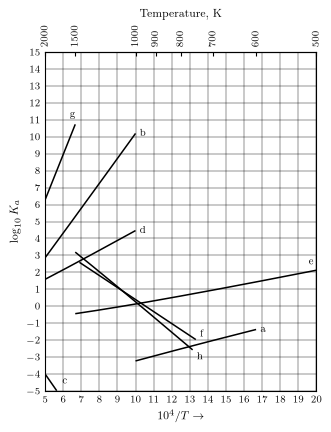

In [8]:
LN10 = np.log(10.0)
RXN = {k: Reaction.parse(eq).check_balance() for k, eq in REACTIONS.items()}

def logK(k, T):
    """log10 Ka for one of the eight, at an array of temperatures."""
    T = np.atleast_1d(np.asarray(T, dtype=float))
    if k == "(c)": v = np.array([ln_Ka_c(float(t)) for t in T])
    elif k == "(g)": v = np.array([ln_Ka_g(float(t)) for t in T])
    else: v = np.array([float(RXN[k].ln_Ka(float(t))) for t in T])
    return v/LN10

# THE PRESENTATION, and every part of it earns its place:
#   * 10^4/T along the bottom, 5 to 20, so Eq. 13.1-22b's linearity is what the eye sees;
#   * a second, non-linear Temperature scale across the top, which is what the caption's
#     "as a function of temperature" is describing;
#   * log10 Ka, which is how Fig. 13.1-3 labels the same quantity;
#   * the unit grid, because the figure is read off rather than admired;
#   * and each reaction drawn only over its own window.
#
# THE WINDOWS ARE THE REASON THE ORDINATE FITS IN TWENTY DECADES. Carried to 400 K
# every curve leaves the frame -- (b) alone reaches +32 and (c) reaches -42 -- and a figure
# that holds all eight over the full range needs a hundred decades and resolves nothing.
# The windows are an EDITORIAL choice, not a computed one.
WINDOW = {"(a)": (600., 1000.), "(b)": (1000., 2000.), "(c)": (1000., 2000.),
          "(d)": (1000., 2000.), "(e)": (500., 1500.), "(f)": (750., 1450.),
          "(g)": (1500., 2000.), "(h)": (760., 1500.)}
# Where each letter sits relative to the end of its own segment, in points: (g) above its
# end, (e) inside the right-hand frame rather than outside it, and (f)/(h) pushed apart
# because their ends are only 0.4 decade apart.
LABEL = {"(a)": (3, 0, "left"), "(b)": (3, 0, "left"), "(c)": (4, 7, "left"),
         "(d)": (3, 0, "left"), "(e)": (-2, 6, "right"), "(f)": (3, 4, "left"),
         "(g)": (-2, 7, "center"), "(h)": (3, -5, "left")}
YLO, YHI, XLO, XHI = -5.0, 15.0, 5.0, 20.0
TOP_T = (2000, 1500, 1000, 900, 800, 700, 600, 500)

fig2, ax = plt.subplots(figsize=(3.5, 4.4))
for k in sorted(WINDOW):
    Tlo, Thi = WINDOW[k]
    T = np.linspace(Thi, Tlo, 300)
    x, y = 1e4/T, logK(k, T)
    inside = (y >= YLO) & (y <= YHI)           # clip at the frame, do not rescale to fit
    ax.plot(x[inside], y[inside], "-", color="k", lw=1.1, solid_capstyle="butt")
    dx, dy, ha = LABEL[k]
    ax.annotate(k[1], xy=(x[inside][-1], y[inside][-1]), xytext=(dx, dy),
                textcoords="offset points", fontsize=7, va="center", ha=ha)

ax.set_xlim(XLO, XHI); ax.set_ylim(YLO, YHI)
ax.set_xticks(np.arange(XLO, XHI + .1, 1.0))
ax.set_yticks(np.arange(YLO, YHI + .1, 1.0))
ax.grid(True, color="k", lw=0.3)               # black, not gray: the book is printed in ink
ax.set_axisbelow(True)
ax.set_xlabel(r"$10^{4}/T\rightarrow$", fontsize=8)
ax.set_ylabel(r"$\log_{10}K_{a}$", fontsize=8)
ax.tick_params(labelsize=7, length=0)

top = ax.secondary_xaxis("top")
top.set_xticks([1e4/t for t in TOP_T]); top.set_xticklabels([str(t) for t in TOP_T])
top.tick_params(labelsize=7, length=3, direction="in")
for lab in top.get_xticklabels():
    lab.set_rotation(90); lab.set_va("bottom")
top.set_xlabel("Temperature, K", fontsize=8, labelpad=6)

# The numbers behind the art, at the figure's own gridlines.
SHOW = (2000, 1500, 1000, 800, 600, 500)
print(f"log10 Ka{'':>2}" + "".join(f"{t:>9d} K" for t in SHOW))
print(f"{'10^4/T':>10}" + "".join(f"{1e4/t:>11.2f}" for t in SHOW))
for k in sorted(WINDOW):
    lo, hi = WINDOW[k]
    row = "".join(f"{logK(k, t)[0]:11.2f}" if lo <= t <= hi else f"{'--':>11}"
                  for t in SHOW)
    print(f"{k:>10}" + row)
print("\n  '--' is outside the window that curve is drawn over, not a failure to compute.")
print(f"  (c) leaves the bottom of the frame at 10^4/T ="
      f" {np.interp(-YLO, -logK('(c)', np.linspace(2000, 1000, 400)), 1e4/np.linspace(2000, 1000, 400)):.2f}"
      f", so only a stub of it is drawn -- see the note below.")

### What the eight curves say

Each curve is a statement about a real process, and the cell below asserts nine of them
rather than describing them. Four of the eight cross $K_a=1$ somewhere in 400 to 2000 K;
**three of those four cross at a temperature the literature fixes independently**, and those
three are the ones the check list uses.

**A crossing is evidence only for a reaction independently known to have one.** Finding
$K_a=1$ where *this calculation* puts it confirms nothing; the three in the check list are
there because a published value fixes the window in advance. (c) has no crossing anywhere on
the figure, and (g) has none either -- for those two the checks assert the **sign** and the
**direction** instead, which is what a reversed reaction would fail and a magnitude test
would not.

**(c) leaves the bottom of the frame at about 1770 K**, so only a short stub of it is
drawn. SO$_2$ is a very stable molecule: at 1000 K its dissociation sits twelve orders of
magnitude below $K_a=1$, far below anything a twenty-decade frame can show. That the curve
runs off the page is the result, not a defect in the drawing.

**The last check is the strongest, because no single reaction's own data can satisfy it by
accident.** (f) $-$ (h) is the water-gas shift, so those three curves are not independent:
$\log_{10}K_a$ for (e) must equal (f) minus (h) at every temperature. It holds to $10^{-15}$.

In [9]:
T_CHECK = np.linspace(400.0, 2000.0, 400)      # the whole range, not the drawn windows
full = {k: logK(k, T_CHECK) for k in sorted(WINDOW)}

def crossing(k):
    v = full[k]
    s = np.where(np.diff(np.sign(v)))[0]
    return None if not len(s) else float(np.interp(0.0, [v[s[0]], v[s[0]+1]],
                                                   [T_CHECK[s[0]], T_CHECK[s[0]+1]]))

# ONLY reactions whose crossing is known INDEPENDENTLY of this notebook belong here.
# A crossing found where the literature puts it is evidence; a crossing found where THIS
# CALCULATION puts it is not, so a reaction goes in this dict only when a published value
# fixes the window in advance. (c) has no crossing at all and must not be added.
KNOWN = {"(a)": ("ammonia becomes unfavorable on heating", 440, 480),
         "(f)": ("the steam-carbon reaction turns over", 900, 1000),
         "(h)": ("the Boudouard reaction turns over", 930, 1010)}
checks = []
for k, (what, lo, hi) in KNOWN.items():
    T = crossing(k)
    label = f"{T:.0f} K" if T is not None else "NO CROSSING IN RANGE"
    checks.append((f"{k} log10 Ka = 0 at {label} -- {what}",
                   T is not None and lo < T < hi))
checks.append((f"(b) CO oxidation is favorable everywhere, log10 Ka from"
               f" {full['(b)'].min():.0f} to {full['(b)'].max():.0f}",
               bool(np.all(full["(b)"] > 0))))
checks.append(("(d) acetylene is unstable everywhere -- log10 Ka > 0 across the range",
               bool(np.all(full["(d)"] > 0))))
# (g) is ASSOCIATION: O atoms recombine, so Ka is large and POSITIVE, and it grows as the
# gas cools. Write the reaction backwards and every magnitude here is unchanged, so this
# check asserts the SIGN and the DIRECTION -- nothing about |Ka| can see the difference.
checks.append((f"(g) 2 O = O2 is favorable everywhere and grows on cooling:"
               f" log10 Ka = {full['(g)'][-1]:.0f} at 2000 K and {full['(g)'][0]:.0f}"
               f" at 400 K",
               bool(np.all(full["(g)"] > 0)) and full["(g)"][0] > full["(g)"][-1]))
# (c) is DISSOCIATION of a very stable molecule -- unfavorable everywhere, and off the
# bottom of the figure's frame over almost all of it.
T_exit = float(np.interp(-YLO, -full['(c)'][::-1], T_CHECK[::-1]))
checks.append((f"(c) SO2 = SO + 1/2 O2 is unfavorable everywhere: log10 Ka ="
               f" {full['(c)'][-1]:.1f} at 2000 K, and below the frame's floor already"
               f" at {T_exit:.0f} K",
               bool(np.all(full["(c)"] < 0)) and crossing("(c)") is None))
checks.append(("every curve rises or falls monotonically in 1/T, as Eq. 13.1-22b requires"
               " of a reaction whose dH does not change sign",
               all(bool(np.all(np.diff(v) > 0)) or bool(np.all(np.diff(v) < 0))
                   for v in full.values())))
# (f) - (h) is the water-gas shift (e): a relation among three of the curves that no
# single reaction's own data can satisfy by accident.
resid = np.max(np.abs((full["(f)"] - full["(h)"]) - full["(e)"]))
checks.append((f"(f) - (h) = (e), the water-gas shift, to {resid:.1e} in log10 Ka", resid < 1e-9))
for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(o for _, o in checks)

  PASS  (a) log10 Ka = 0 at 460 K -- ammonia becomes unfavorable on heating
  PASS  (f) log10 Ka = 0 at 947 K -- the steam-carbon reaction turns over
  PASS  (h) log10 Ka = 0 at 971 K -- the Boudouard reaction turns over
  PASS  (b) CO oxidation is favorable everywhere, log10 Ka from 3 to 32
  PASS  (d) acetylene is unstable everywhere -- log10 Ka > 0 across the range
  PASS  (g) 2 O = O2 is favorable everywhere and grows on cooling: log10 Ka = 6 at 2000 K and 59 at 400 K
  PASS  (c) SO2 = SO + 1/2 O2 is unfavorable everywhere: log10 Ka = -4.0 at 2000 K, and below the frame's floor already at 1770 K
  PASS  every curve rises or falls monotonically in 1/T, as Eq. 13.1-22b requires of a reaction whose dH does not change sign
  PASS  (f) - (h) = (e), the water-gas shift, to 7.5e-15 in log10 Ka


## Staging the art

    pdf/Figure_13.1-2.pdf   ->   deliverables/figures/print-bw/ch13/c13f002.pdf

In [10]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.1-2.pdf"
fig2.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.1-2.pdf

  typography: LaTeX Computer Modern


## Your turn

1. Illustration 13.1-4(b) dilutes and the conversion falls; Illustration 13.1-2 dilutes and
   it rises. The notebook attributes the difference to the sign of $\Delta\nu$ and
   separates the ratio effect from the dilution effect numerically. **Now do it
   algebraically**: show that at fixed $T$ and $P$, adding $N$ moles of inert to a
   stoichiometric feed multiplies $K_y$ by $(1+N/N_0)^{\Delta\nu}$, and say what that
   predicts for a reaction with $\sum_i\nu_i=0$.
2. Part (c) is run at constant volume and lands between the constant-pressure answer at
   4 bar and the one at its own final pressure. Is that always true? Construct the argument
   from the fact that $P$ falls monotonically with $X$ when $\Delta\nu<0$, then test it for
   a reaction with $\Delta\nu>0$ -- N$_2$O$_4$ dissociation will do -- and report which side
   the constant-volume answer falls on there.
3. **Only $K_a$ is a function of temperature alone, and $K_p$ has units.** Write out the
   units of $K_p$ and $K_y$ for a reaction with $\Delta\nu=-1$, $0$ and $+2$, and explain
   why a table of "equilibrium constants" that does not state the standard state is
   useless. Then find one place in Chapter 13 where the standard state is stated and one
   where you have to infer it.
4. Figure 13.1-2's curves are nearly straight in $1/T$ but not exactly. For each of the
   six reactions the appendix reaches, fit a straight line over 400 to 2000 K and report
   the largest departure in $\log_{10}K_a$ and the heat of reaction the slope implies. Which
   reaction is *least* straight, and what does that say about its $\Delta_{\rm rxn}C_P$?
5. Reactions (c) and (g) are computed here from JANAF data because Appendix A.IV has
   neither SO nor atomic oxygen. **Decide whether it should.** Find $\Delta_fH^{\circ}$ and
   $S^{\circ}$ for O(g), H(g) and SO(g) in a reference source, and say which reactions in
   this chapter would become computable if the appendix carried them -- then say whether
   that is worth three rows in a printed table students mostly use below 1500 K.
6. The Boudouard reaction (h) and the steam-carbon reaction (f) both cross $K_a = 1$
   near 950 K, and both consume solid carbon. Their difference, (f) $-$ (h), is the
   water-gas shift (e) reversed. The notebook asserts that identity to $10^{-9}$; **now
   explain why (e) crosses $K_a=1$ at a completely different temperature from either
   parent**, and why the identity holds no matter what the parents' data are.
7. Reaction (g) is written 2O $\to$ O$_2$ -- **association**, not dissociation. Write it the
   other way and every $\log_{10}K_a$ in the table keeps its magnitude and changes sign.
   **Find the check in the notebook that would catch that, and the two that would not**, and
   then state the general rule about what a test on $|K_a|$ can and cannot establish.
8. (c) leaves the bottom of the frame at about 1770 K and only a stub of it is drawn. **Decide
   whether that is the right call.** Work out what ordinate range would be needed to carry (c)
   from 2000 K down to 1000 K, report what that range does to the other seven curves, and say
   which figure you would rather read. Then find one other figure in this chapter where the
   same trade was made the other way.